# Crop Recommendation System

Given soil nutrients (N, P, K), pH and local weather (temperature, humidity, rainfall), which of 22 crops is the best fit?

**Plan**
1. Load and sanity-check the data
2. Explore how the features differ between crops
3. Compare a few models with cross-validation
4. Evaluate the winner on a held-out test set
5. Save the model for the Streamlit app (`app.py`)

One design choice worth noting: all preprocessing lives inside a scikit-learn `Pipeline`. That way new inputs are handled with the same settings learned from the training data, instead of being re-scaled on their own.

In [1]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED = 42
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

## 1. Load and check the data

In [2]:
df = pd.read_csv("../data/Crop_recommendation.csv")
print("Rows, columns:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
df.head()

Rows, columns: (2200, 8)
Missing values: 0
Duplicate rows: 0


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.55,36.92,0.00,21.00,37.00,84.25,140.00
P,2200.0,53.36,32.99,5.00,28.00,51.00,68.00,145.00
K,2200.0,48.15,50.65,5.00,20.00,32.00,49.00,205.00
temperature,2200.0,25.62,5.06,8.83,22.77,25.60,28.56,43.68
humidity,2200.0,71.48,22.26,14.26,60.26,80.47,89.95,99.98
ph,2200.0,6.47,0.77,3.50,5.97,6.43,6.92,9.94
rainfall,2200.0,103.46,54.96,20.21,64.55,94.87,124.27,298.56


In [4]:
# 22 crops, 100 samples each: the classes are perfectly balanced,
# so plain accuracy is a fair metric here.
df["label"].value_counts().describe()[["count", "min", "max"]]

count     22.0
min      100.0
max      100.0
Name: count, dtype: float64

## 2. Explore the features

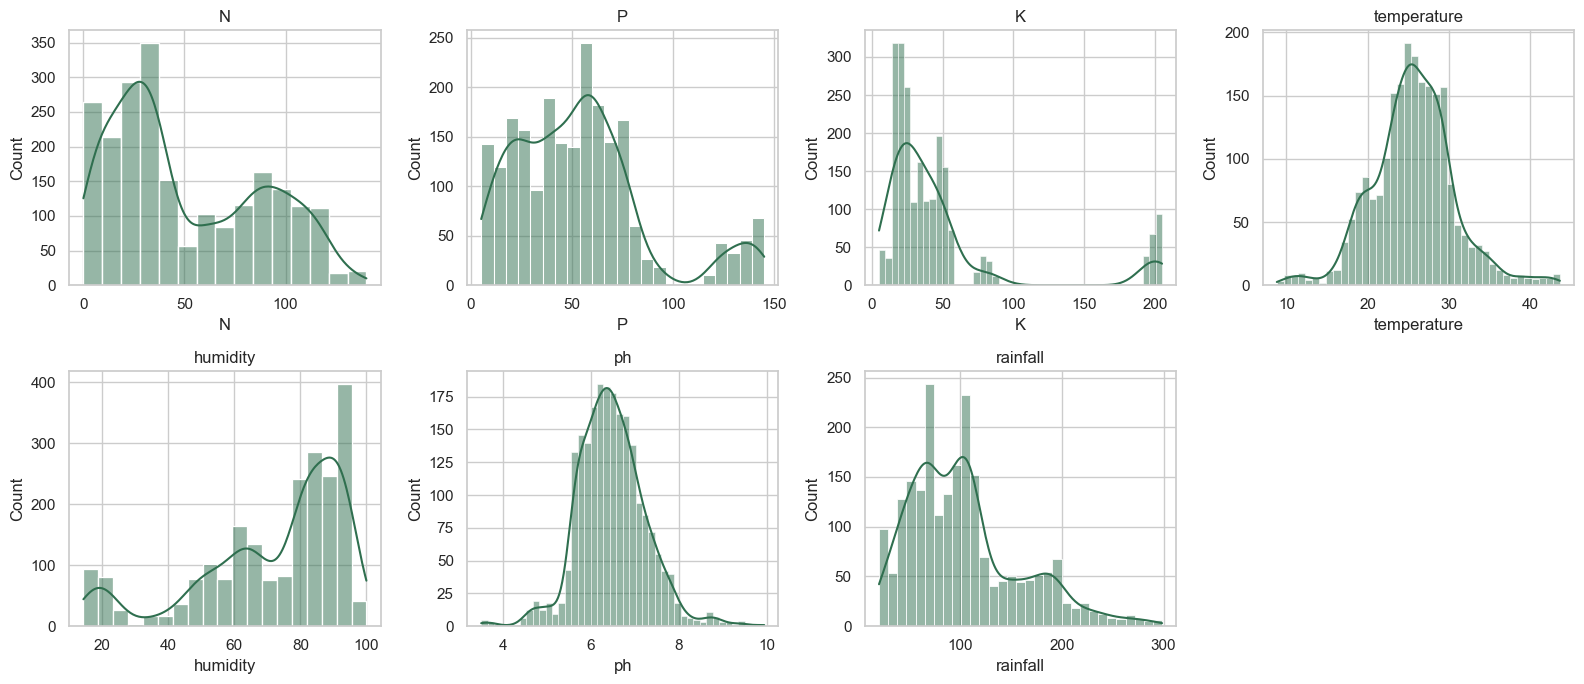

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.histplot(df[col], kde=True, ax=ax, color="#2f6f4f")
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

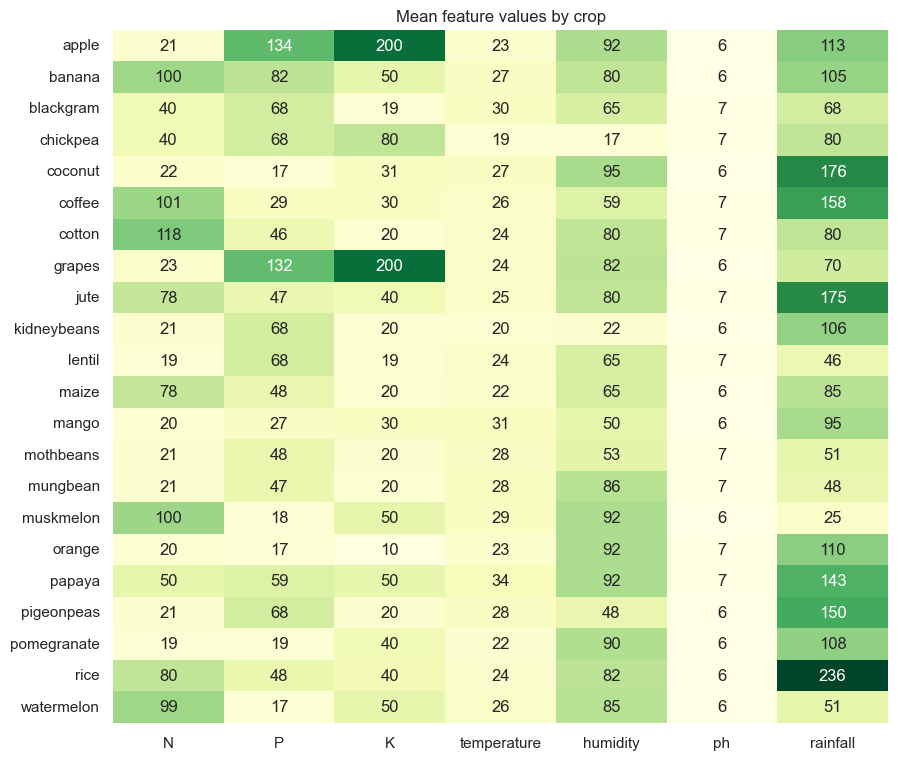

In [6]:
# Average conditions per crop: this is what the model has to separate.
profile = df.groupby("label")[FEATURES].mean().round(1)
plt.figure(figsize=(10, 9))
sns.heatmap(profile, annot=True, fmt=".0f", cmap="YlGn", cbar=False)
plt.title("Mean feature values by crop")
plt.ylabel("")
plt.show()

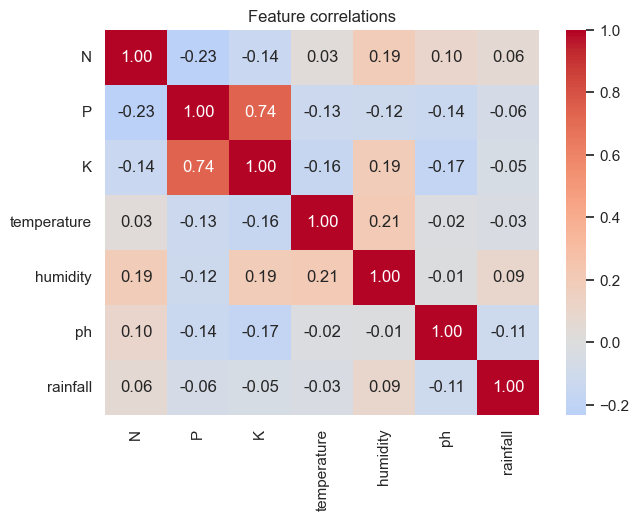

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlations")
plt.show()

P and K are strongly correlated, mostly because a few crops such as grapes and apple sit at very high values of both. The other features are largely independent, so each adds its own information.

## 3. Split the data and compare models

In [8]:
X = df[FEATURES]
y = df["label"]

# stratify keeps the 22 crops evenly represented in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(X_train.shape, X_test.shape)

(1760, 7) (440, 7)


In [9]:
candidates = {
    "Logistic Regression": Pipeline([("scale", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=2000))]),
    "KNN": Pipeline([("scale", StandardScaler()),
                     ("clf", KNeighborsClassifier(n_neighbors=5))]),
    # Trees don't need scaled inputs, so no scaler here
    "Random Forest": Pipeline([("clf", RandomForestClassifier(
        n_estimators=200, random_state=SEED, n_jobs=-1))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv)
    print(f"{name:<20} {scores.mean():.3f} +/- {scores.std():.3f}")

Logistic Regression  0.968 +/- 0.007
KNN                  0.965 +/- 0.012
Random Forest        0.994 +/- 0.005


Random Forest is the strongest of the three, and it also gives class probabilities and feature importances, which the web app uses.

## 4. Evaluate on the held-out test set

In [10]:
model = candidates["Random Forest"]
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

Test accuracy: 0.9955

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
    

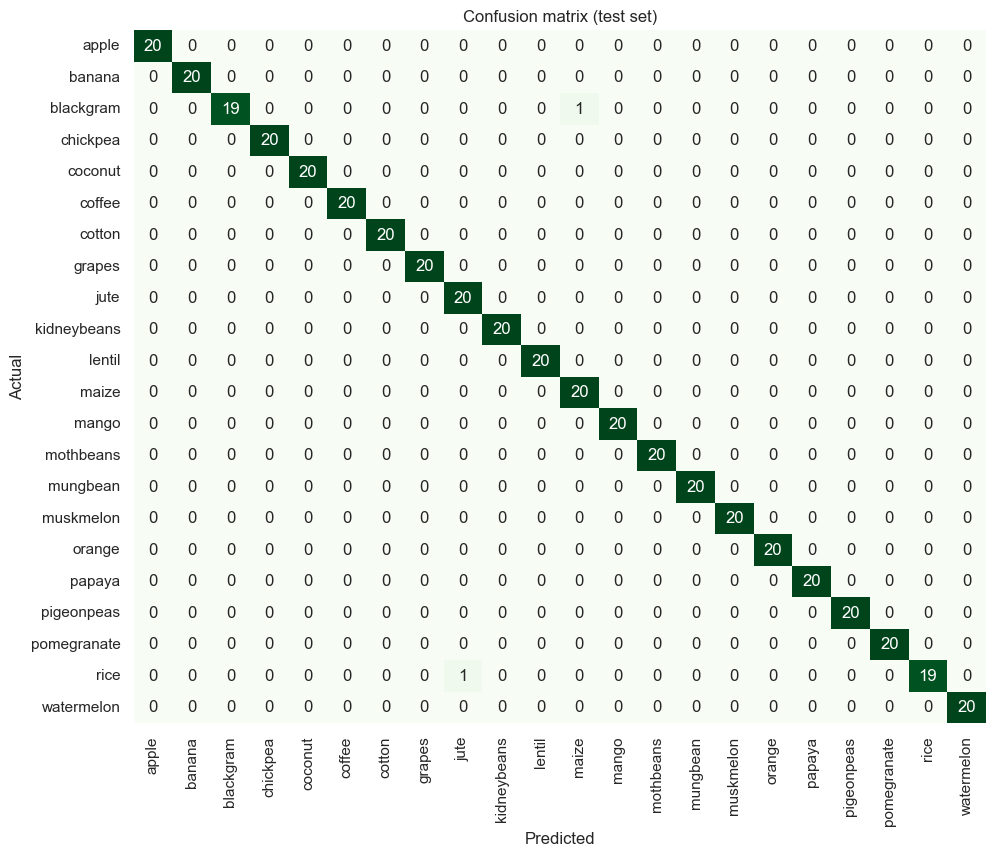

In [11]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix (test set)")
plt.show()

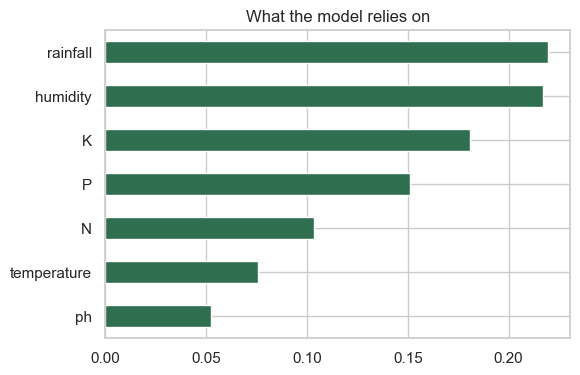

In [12]:
importances = pd.Series(model.named_steps["clf"].feature_importances_, index=FEATURES)
importances.sort_values().plot.barh(color="#2f6f4f", figsize=(6, 4),
                                    title="What the model relies on")
plt.show()

## 5. Try it on one example

In [13]:
def recommend(N, P, K, temperature, humidity, ph, rainfall, top=3):
    """Return the top crops with their probabilities for one set of conditions."""
    row = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]], columns=FEATURES)
    proba = model.predict_proba(row)[0]
    best = np.argsort(proba)[::-1][:top]
    return [(model.classes_[i], round(float(proba[i]), 3)) for i in best]

recommend(90, 42, 43, 20.9, 82.0, 6.5, 202.9)

[('rice', 0.935), ('jute', 0.065), ('pomegranate', 0.0)]

## 6. Save the model

The final model is refit on **all** the data before saving, since the test set has already done its job of estimating performance.

In [14]:
final_model = candidates["Random Forest"].fit(X, y)
joblib.dump(final_model, "../models/crop_model.joblib", compress=3)
print("Saved ../models/crop_model.joblib")

Saved ../models/crop_model.joblib
